In [1]:
# from google.colab import drive
# drive.mount('/content/drive')

# zip_file_path = '/content/drive/MyDrive/Colab Notebooks/GEO-Photos-for-Image-Processing.zip'
# # Ensure the file exists before attempting to unzip
# import os
# if os.path.exists(zip_file_path):
#     print(f'Unzipping {zip_file_path}...')
#     !unzip -q "{zip_file_path}" -d .
#     print('Unzipping complete.')
# else:
#     print(f'Error: The file {zip_file_path} was not found. Please ensure it exists in your Google Drive.')

### 1. Setup: Import Libraries and Define Image Directories
First, I'll import all the necessary libraries for image processing, model building, and data handling. Then, I'll define the paths to your image directories.

In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Define the base directory where the unzipped folders are located
base_dir = r'C:\Users\HP\DevChips\PMAY\dataset'

image_dirs = [
    os.path.join(base_dir, 'plinth'),
    os.path.join(base_dir, 'complete-level'),
    os.path.join(base_dir, 'roof-cast')
]

# Verify that directories exist
for d in image_dirs:
    if not os.path.exists(d):
        print(f"Warning: Directory '{d}' does not exist. Please check the path.")
    else:
        print(f"Found directory: '{d}'")

Found directory: 'C:\Users\HP\DevChips\PMAY\dataset\plinth'
Found directory: 'C:\Users\HP\DevChips\PMAY\dataset\complete-level'
Found directory: 'C:\Users\HP\DevChips\PMAY\dataset\roof-cast'


### 2. Data Collection and Labeling
Now, I'll collect all image file paths and assign a label to each based on its directory name. This data will be stored in a Pandas DataFrame.

In [3]:
image_paths = []
labels = []

for img_dir in image_dirs:
    label = os.path.basename(img_dir) # Use folder name as label
    for img_name in os.listdir(img_dir):
        # Only consider common image file extensions
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
            image_paths.append(os.path.join(img_dir, img_name))
            labels.append(label)

df = pd.DataFrame({'path': image_paths, 'label': labels})

# Display some information about the collected data
print(f"Total images found: {len(df)}")
print("Label distribution:")
display(df['label'].value_counts())
display(df.head())

Total images found: 12626
Label distribution:


label
plinth            4504
complete-level    4101
roof-cast         4021
Name: count, dtype: int64

,path,label
0,C:\Users\HP\DevChips\PMAY\dataset\plinth\71491...,plinth
1,C:\Users\HP\DevChips\PMAY\dataset\plinth\71491...,plinth
2,C:\Users\HP\DevChips\PMAY\dataset\plinth\71491...,plinth
3,C:\Users\HP\DevChips\PMAY\dataset\plinth\71491...,plinth
4,C:\Users\HP\DevChips\PMAY\dataset\plinth\71491...,plinth


### 3. Data Preprocessing - Train/Validation/Test Split
To properly evaluate the model, I'll split the dataset into training, validation, and test sets. The training set will be used for model training, the validation set for tuning hyperparameters and monitoring overfitting, and the test set for final performance evaluation.

In [4]:
# Split data into training and temporary (validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(df['path'], df['label'], test_size=0.3, random_state=42, stratify=df['label'])

# Split temporary data into validation and test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Create DataFrames for each split
train_df = pd.DataFrame({'path': X_train, 'label': y_train})
val_df = pd.DataFrame({'path': X_val, 'label': y_val})
test_df = pd.DataFrame({'path': X_test, 'label': y_test})

print(f"Training images: {len(train_df)}")
print(f"Validation images: {len(val_df)}")
print(f"Test images: {len(test_df)}")

# Get the number of classes
num_classes = len(df['label'].unique())
class_names = sorted(df['label'].unique().tolist())
print(f"Number of classes: {num_classes}")
print(f"Class names: {class_names}")

Training images: 8838
Validation images: 1894
Test images: 1894
Number of classes: 3
Class names: ['complete-level', 'plinth', 'roof-cast']


### 4. Data Augmentation and Generators
To prevent overfitting and make the model more robust, I'll apply data augmentation techniques to the training set. `ImageDataGenerator` will be used to create batches of image data for efficient feeding into the model.

In [ ]:
IMG_HEIGHT = 224 # Standard input size for many pre-trained models
IMG_WIDTH = 224
BATCH_SIZE = 32

# Data augmentation for training imagesv
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normalize pixel values to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Only rescale for validation and test images (no augmentation)
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Create data generators
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

validation_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False, # Do not shuffle validation data
    seed=42
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='path',
    y_col='label',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # Do not shuffle test data
)


Found 8838 validated image filenames belonging to 3 classes.
Found 1894 validated image filenames belonging to 3 classes.
Found 1894 validated image filenames belonging to 3 classes.


### 5. Model Building - Transfer Learning with MobileNetV2
For robust image classification, I'll use a pre-trained Convolutional Neural Network (CNN) via transfer learning. MobileNetV2 is a good choice as it's efficient and performs well. I'll load its pre-trained weights (trained on ImageNet), freeze its layers, and add a custom classification head tailored to your specific task.

In [13]:
# Load the pre-trained MobileNetV2 model, excluding the top classification layer
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3))

# Freeze the base model layers so they are not updated during training
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False
# Add custom classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Convert features to a single vector
x = Dense(128, activation='relu')(x) # Add a fully connected layer
predictions = Dense(num_classes, activation='softmax')(x) # Output layer with 'softmax' for multi-class classification

model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 1,370,435 (5.23 MB)

 Non-trainable params: 1,051,904 (4.01 MB)

### 6. Model Training
Now, I'll train the model using the `train_generator` and validate its performance with `validation_generator`. Training progress will be monitored for loss and accuracy on both sets.

In [7]:
from PIL import Image
print("Pillow installed successfully")

Pillow installed successfully


In [8]:
import sys
print(sys.executable)

from PIL import Image
print("Pillow OK")

c:\Users\HP\DevChips\PMAY\venv\.venv\Scripts\python.exe
Pillow OK


In [9]:
import tensorflow as tf
import keras
import PIL

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("Pillow:", PIL.__version__)

TensorFlow: 2.21.0
Keras: 3.14.1
Pillow: 12.2.0


In [10]:
from tensorflow.keras.utils import load_img

img = load_img(r"C:\Users\HP\DevChips\PMAY\dataset\plinth\71491A1713867862.jpg")


Epoch 1/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 240s 865ms/step - accuracy: 0.7679 - loss: 0.5574 - val_accuracy: 0.7645 - val_loss: 0.5802
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 194s 701ms/step - accuracy: 0.7800 - loss: 0.5499 - val_accuracy: 0.7677 - val_loss: 0.5734
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 257s 927ms/step - accuracy: 0.7825 - loss: 0.5357 - val_accuracy: 0.7761 - val_loss: 0.5615
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 240s 869ms/step - accuracy: 0.7865 - loss: 0.5260 - val_accuracy: 0.7756 - val_loss: 0.5564
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 284s 1s/step - accuracy: 0.7890 - loss: 0.5161 - val_accuracy: 0.7767 - val_loss: 0.5501
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 281s 1s/step - accuracy: 0.8005 - loss: 0.4987 - val_accuracy: 0.7825 - val_loss: 0.5428
Epoch 7/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 183s 658ms/step - accuracy: 0.8020 - loss: 0.4892 - val_accuracy: 0.7841 - val_loss: 0.5409
Epoch 8/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 151s 543ms/step - accuracy: 0.8037 - loss:

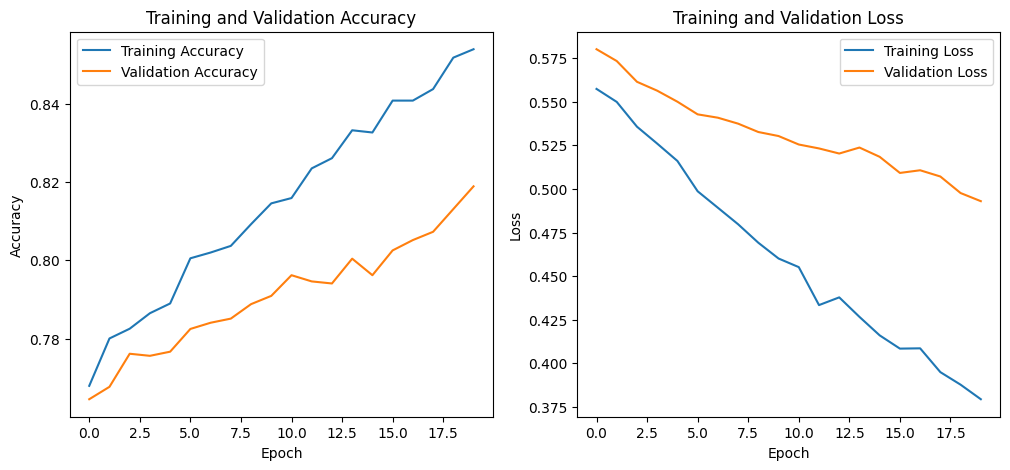

In [16]:
EPOCHS = 20 # You can adjust this number

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=validation_generator
)

# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### 7. Model Evaluation
Finally, I'll evaluate the trained model on the unseen test set to get an unbiased measure of its performance. I'll use a classification report and a confusion matrix to assess precision, recall, F1-score, and identify any misclassifications.

Evaluating model on test data...
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 387ms/step - accuracy: 0.8105 - loss: 0.4964
Test Loss: 0.4964
Test Accuracy: 0.8105
60/60 ━━━━━━━━━━━━━━━━━━━━ 23s 377ms/step

Classification Report:
                precision    recall  f1-score   support

complete-level       0.82      0.83      0.82       616
        plinth       0.89      0.82      0.85       675
     roof-cast       0.72      0.78      0.75       603

      accuracy                           0.81      1894
     macro avg       0.81      0.81      0.81      1894
  weighted avg       0.82      0.81      0.81      1894



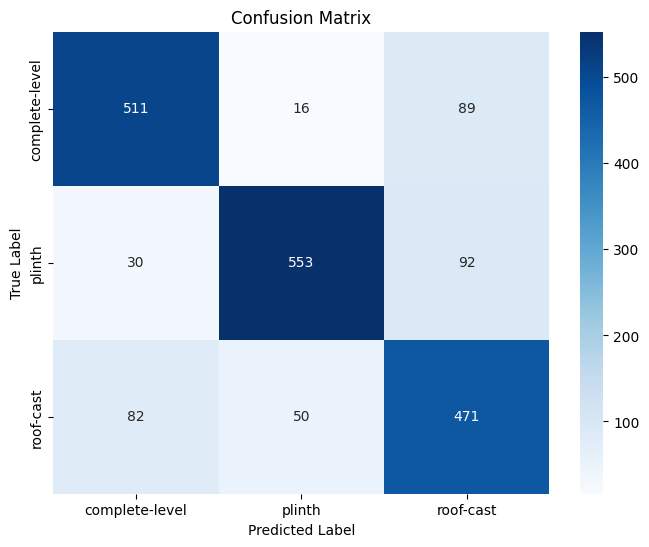

In [17]:
print("Evaluating model on test data...")
eval_results = model.evaluate(test_generator)
print(f"Test Loss: {eval_results[0]:.4f}")
print(f"Test Accuracy: {eval_results[1]:.4f}")

# Predict classes for the test set
Y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(Y_pred, axis=1)
y_true_classes = test_generator.classes

# Get class labels from the generator
labels = list(test_generator.class_indices.keys())

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=labels))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [21]:
# 1. Save the trained model
model_save_path = 'MMAY_Image_2-0.h5'
model.save(model_save_path)
print(f"Model saved successfully to {model_save_path}")

Model saved successfully to MMAY_Image_2-0.h5


Model saved successfully to MMAY_Image_2-0.h5

Select an image for classification:
Selected file: "71504B1717677422.jpg"
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 805ms/step


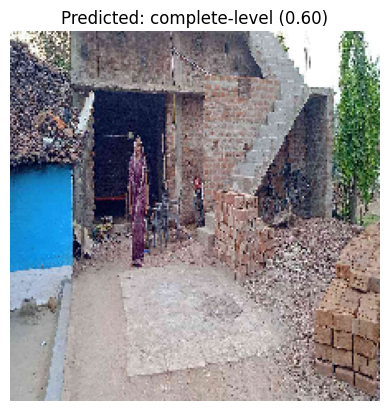

Uploaded image classified as: complete-level with confidence 0.60


In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import os



# 2. Function to preprocess and predict on an uploaded image
def predict_uploaded_image(model, img_path, class_names, img_height, img_width):
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(predictions[0])

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

    print(f"Uploaded image classified as: {predicted_class_name} with confidence {confidence:.2f}")
    return predicted_class_name, confidence

# 3. Open a file dialog to select an image
print("\nSelect an image for classification:")

try:
    import tkinter as tk
    from tkinter import filedialog

    root = tk.Tk()
    root.withdraw()  # Hide the root window
    root.attributes('-topmost', True)  # Bring dialog to front

    img_path = filedialog.askopenfilename(
        title="Select an image",
        filetypes=[("Image files", "*.jpg *.jpeg *.png *.bmp *.gif *.tiff"), ("All files", "*.*")]
    )
    root.destroy()

except Exception:
    # Fallback: manually enter the path
    img_path = input("Enter the full path to your image: ").strip()

if img_path and os.path.exists(img_path):
    print(f'Selected file: "{os.path.basename(img_path)}"')
    predict_uploaded_image(model, img_path, class_names, IMG_HEIGHT, IMG_WIDTH)
else:
    print("No file selected or file not found.")

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt

# Function to preprocess and predict on an uploaded image
def predict_uploaded_image(model, img_path, class_names, img_height, img_width):
    img = image.load_img(img_path, target_size=(img_height, img_width))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array /= 255.0  # Rescale the image

    predictions = model.predict(img_array)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    confidence = np.max(predictions[0])

    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class_name} ({confidence:.2f})")
    plt.axis('off')
    plt.show()

    print(f"Uploaded image classified as: {predicted_class_name} with confidence {confidence:.2f}")
    return predicted_class_name, confidence

# Allow user to upload an image and get classification
print("\nUpload an image for classification:")
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}"')
    # Make predictions using the previously trained model and defined parameters
    predict_uploaded_image(model, fn, class_names, IMG_HEIGHT, IMG_WIDTH)